In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
auto = pd.read_csv('Auto.csv')
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [10]:
print(auto[auto.select_dtypes(object).columns])
print(auto.select_dtypes(include='number'))

    horsepower                       name
0          130  chevrolet chevelle malibu
1          165          buick skylark 320
2          150         plymouth satellite
3          150              amc rebel sst
4          140                ford torino
..         ...                        ...
392         86            ford mustang gl
393         52                  vw pickup
394         84              dodge rampage
395         79                ford ranger
396         82                 chevy s-10

[397 rows x 2 columns]
      mpg  cylinders  displacement  weight  acceleration  year  origin
0    18.0          8         307.0    3504          12.0    70       1
1    15.0          8         350.0    3693          11.5    70       1
2    18.0          8         318.0    3436          11.0    70       1
3    16.0          8         304.0    3433          12.0    70       1
4    17.0          8         302.0    3449          10.5    70       1
..    ...        ...           ...     ...    

In [11]:
auto.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [30]:
new_df = auto.drop(auto.iloc[10:85, :].index)
new_df.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000
mean,24.409317,5.378882,187.680124,2936.807453,15.700621,77.130435,1.596273
std,7.913357,1.657398,100.120925,810.987533,2.706436,3.131849,0.815572
min,11.000000,3.000000,68.000000,1649.000000,8.500000,70.000000,1.000000
25%,18.000000,4.000000,100.250000,2216.000000,14.000000,75.000000,1.000000
50%,23.900000,4.000000,145.500000,2797.500000,15.500000,77.000000,1.000000
75%,30.650000,6.000000,250.000000,3516.000000,17.275000,80.000000,2.000000
max,46.600000,8.000000,455.000000,4997.000000,24.800000,82.000000,3.000000


In [31]:
subset_df = auto.drop(auto.index[9:85])

# 2. Select only numeric columns (predictors)
numeric_predictors = subset_df.select_dtypes(include=["number"])

# 3. Calculate mean, standard deviation, min, and max
summary = numeric_predictors.agg(["mean", "std", "min", "max"])

# 4. Calculate the range (Max - Min) and format the final table
summary.loc["range"] = summary.loc["max"] - summary.loc["min"]
final_stats = summary.loc[["range", "mean", "std"]]

# Display the results
print(final_stats)

             mpg  cylinders  displacement       weight  acceleration  \
range  35.600000   5.000000    387.000000  3348.000000     16.300000   
mean   24.438629   5.370717    187.049844  2933.962617     15.723053   
std     7.908184   1.653486     99.635385   810.642938      2.680514   

            year    origin  
range  12.000000  2.000000  
mean   77.152648  1.598131  
std     3.111230  0.816163  


C:\Users\pc\AppData\Local\Temp\ipykernel_6668\4045347999.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  pd.plotting.scatter_matrix(auto.select_dtypes(include=["number"]), ax=ax);


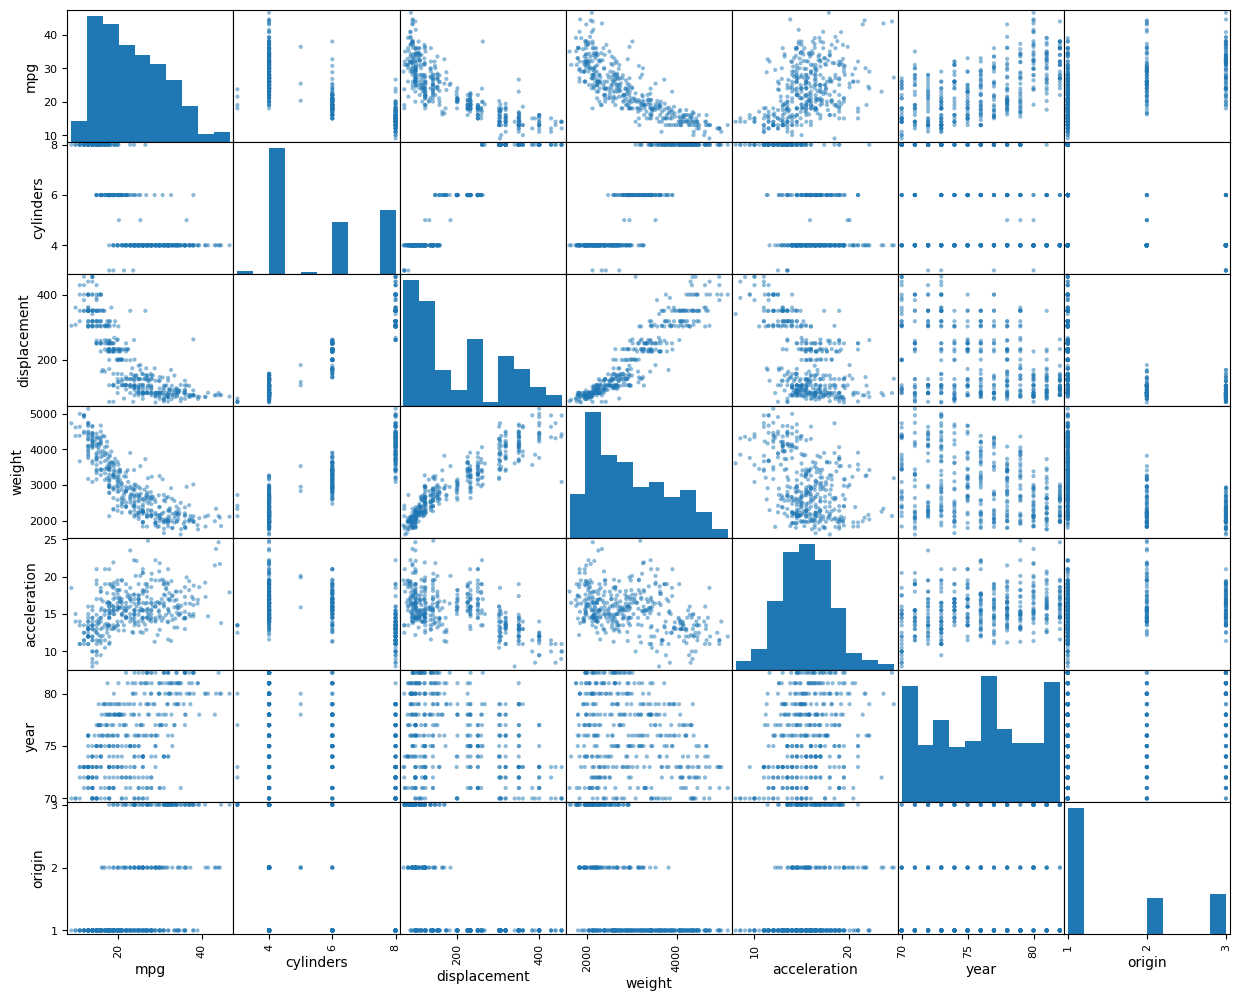

In [38]:
fig, ax = plt.subplots(figsize=(15, 12))
pd.plotting.scatter_matrix(auto.select_dtypes(include=["number"]), ax=ax);

(f) Suppose that we wish to predict gas mileage (mpg) on the basis of the other variables. Do your plots suggest that any of the other variables might be useful in predicting mpg? Justify your answer.

`displacement`, `weight` and `acceleration` might be useful variable for predicting mpg, because they show some kind of linearity and correlations.